# CCNF Training Pipeline: Synthetic Data → Training → Inference

This notebook demonstrates the complete PtychoPINN workflow using the
**PC-CCNF** (Position-Conditioned Shared Canvas + Neural Field) architecture:

1. **Load a reference dataset** — extract the probe function and material distribution
2. **Fit distribution models** — histogram, statistics, and GMM from the reference object
3. **Select an object generation method** — choose from 13 available methods
4. **Generate and visualize synthetic objects** — inspect before committing
5. **Generate the full synthetic dataset** — write NPZ files for training
6. **Train a CCNF model** — via `train_ccnf.main()` with indexed dataloader
7. **Run inference** — reconstruct using `inference_indexed.py` pipeline
8. **Visualize results** — amplitude/phase comparisons and Re-Im distributions

### How this differs from `full_training_pipeline.ipynb`

**Sections 1–5 are identical** — synthetic data generation is architecture-agnostic.
The differences begin at training (section 6):

| Aspect | UNet (default) | PC-CCNF (this notebook) |
|---|---|---|
| **Training entry point** | `main_lightning()` | `train_ccnf.main()` |
| **Dataloader** | `PtychoDataset` — pre-groups C patches into memory map | `PtychoDatasetIndexed` — stores each pattern once, gathers groups at runtime |
| **Config delivery** | `existing_config` tuple passed directly | JSON config file serialized to disk |
| **Inference** | `load_and_predict_lightning()` (single call) | 4-step pipeline: load → build dataset → reconstruct → save |
| **Model forward pass** | Encoder-decoder ignores scan positions | Autoencoder receives positions + probe for geometry-aware fusion |

### Architecture Notes
The PC-CCNF model combines:
- **FNO+CNN hybrid encoder** — weight-shared across patches
- **Geometry-tagged cross-attention fusion** — assembles per-patch latents onto a shared canvas
- **Neural field decoder** — coordinate-conditioned MLP with Fourier positional encoding

### Prerequisites
- GPU required (training uses `accelerator='gpu'`)
- PtychoPINN installed with `pip install -e .[torch]`
- A reference NPZ file containing `objectGuess` and `probeGuess` keys

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))

import json
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from pathlib import Path
from scipy.ndimage import gaussian_filter
from IPython.display import SVG, display
import glob

# Data generation
from ptycho_torch.datagen.objects import (
    fit_gmm_from_objects,
    compute_reim_statistics,
    create_density_histogram_reim,
)
from ptycho_torch.datagen.datagen import (
    simulate_synthetic_objects,
    simulate_multiple_experiments,
)

# Configuration
from ptycho_torch.config_params import (
    DataConfig, ModelConfig, TrainingConfig, InferenceConfig, DatagenConfig,
    update_existing_config,
)

# CCNF Training
from ptycho_torch.beta_modules.train_ccnf import main as train_ccnf_main

# CCNF Inference
from ptycho_torch.beta_modules.inference_indexed import (
    load_model_from_checkpoint,
    build_indexed_dataset,
    run_reconstruction,
    save_results,
)

# Utilities
from ptycho_torch.utils import remove_all_files, config_to_json_serializable_dict

%matplotlib inline

In [2]:
# ============================================================
# USER CONFIGURATION — edit these paths and parameters
# ============================================================

# Reference NPZ file (must contain objectGuess and probeGuess)
NPZ_BASE_PATH = '../../data/amsc_ic2'
NPZ_PATH = glob.glob(NPZ_BASE_PATH + '/*.npz')[0]

# Patch size N (must match probe spatial dimensions)
N = 128

# Synthetic object canvas size (scales with N)
canvas_scale = N / 64
IMAGE_SIZE = (int(250 * canvas_scale), int(250 * canvas_scale))

# Dataset generation parameters
N_OBJECTS = 4            # Number of unique synthetic objects
DIFF_PER_OBJECT = 7000   # Diffraction patterns per object

# Output directories (relative to project root via ../../data)
SYNTHETIC_DATA_DIR = '../../data/synthetic_pipeline_demo'
TRAINING_OUTPUT_DIR = '../../data/ccnf_training_pipeline_demo'

# Inference test data — must be a separate NPZ file (not the training data)
INFERENCE_NPZ_PATH = '../../data/amsc_ic2'
INFERENCE_OUTPUT_DIR = '../../data/ccnf_inference_pipeline_demo'

# CCNF config path (None = auto-generate from settings below)
CCNF_CONFIG_PATH = None

print(f'Reference NPZ: {NPZ_PATH}')
print(f'Patch size N: {N}')
print(f'Canvas size: {IMAGE_SIZE}')
print(f'Dataset: {N_OBJECTS} objects x {DIFF_PER_OBJECT} patterns each')

Reference NPZ: ../../data/amsc_ic2/AmSC_IC_2_ptychopinn.npz
Patch size N: 128
Canvas size: (500, 500)
Dataset: 4 objects x 7000 patterns each


---
## 1. Load Reference Dataset

Load a reference NPZ file containing:
- `objectGuess` — complex-valued 2D array of the reconstructed object
- `probeGuess` — complex-valued 2D or 3D array (single-mode or multi-mode probe)

The object provides the material Re-Im distribution we want to replicate in synthetic data. The probe is reused directly for diffraction simulation.

In [3]:
npz_data = np.load(NPZ_PATH)
ref_obj = npz_data['objectGuess']
probe = npz_data['probeGuess']

print(f'objectGuess: shape={ref_obj.shape}, dtype={ref_obj.dtype}')
print(f'  Amplitude range: [{np.abs(ref_obj).min():.4f}, {np.abs(ref_obj).max():.4f}]')
print(f'  Re range: [{ref_obj.real.min():.4f}, {ref_obj.real.max():.4f}]')
print(f'  Im range: [{ref_obj.imag.min():.4f}, {ref_obj.imag.max():.4f}]')
print()
print(f'probeGuess: shape={probe.shape}, dtype={probe.dtype}')
if probe.ndim == 3:
    print(f'  Multi-mode probe with {probe.shape[0]} modes')
    print(f'  Spatial dimensions: {probe.shape[1]}x{probe.shape[2]}')
elif probe.ndim == 2:
    print(f'  Single-mode probe: {probe.shape[0]}x{probe.shape[1]}')

objectGuess: shape=(927, 934), dtype=complex64
  Amplitude range: [0.0000, 2.3476]
  Re range: [-1.0651, 2.2443]
  Im range: [-1.7957, 1.6558]

probeGuess: shape=(5, 128, 128), dtype=complex64
  Multi-mode probe with 5 modes
  Spatial dimensions: 128x128


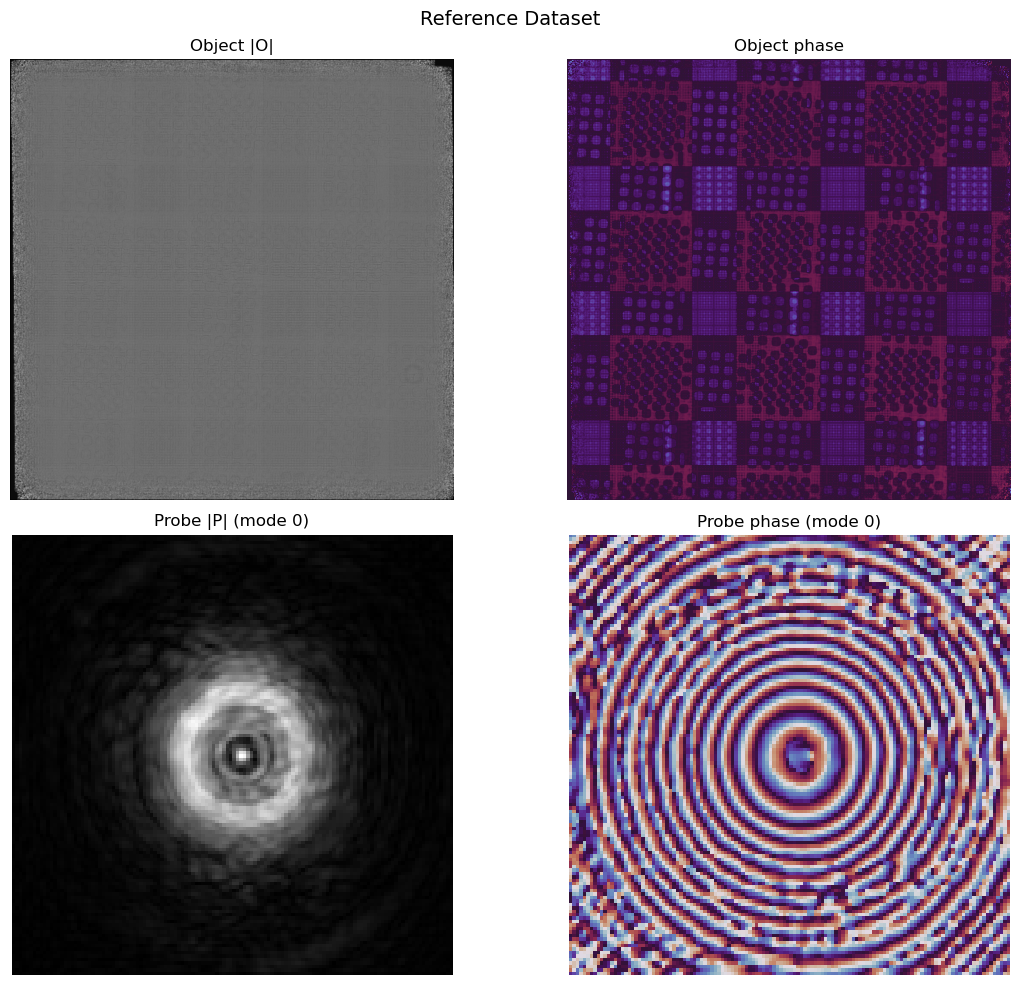

In [4]:
# Visualize reference object and probe
probe_display = probe[0] if probe.ndim == 3 else probe

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(np.abs(ref_obj), cmap='gray')
axes[0, 0].set_title('Object |O|')
axes[0, 0].axis('off')

axes[0, 1].imshow(np.angle(ref_obj), cmap='twilight', vmin=-np.pi, vmax=np.pi)
axes[0, 1].set_title('Object phase')
axes[0, 1].axis('off')

axes[1, 0].imshow(np.abs(probe_display), cmap='gray')
axes[1, 0].set_title('Probe |P| (mode 0)')
axes[1, 0].axis('off')

axes[1, 1].imshow(np.angle(probe_display), cmap='twilight', vmin=-np.pi, vmax=np.pi)
axes[1, 1].set_title('Probe phase (mode 0)')
axes[1, 1].axis('off')

plt.suptitle('Reference Dataset', fontsize=14)
plt.tight_layout()
plt.show()

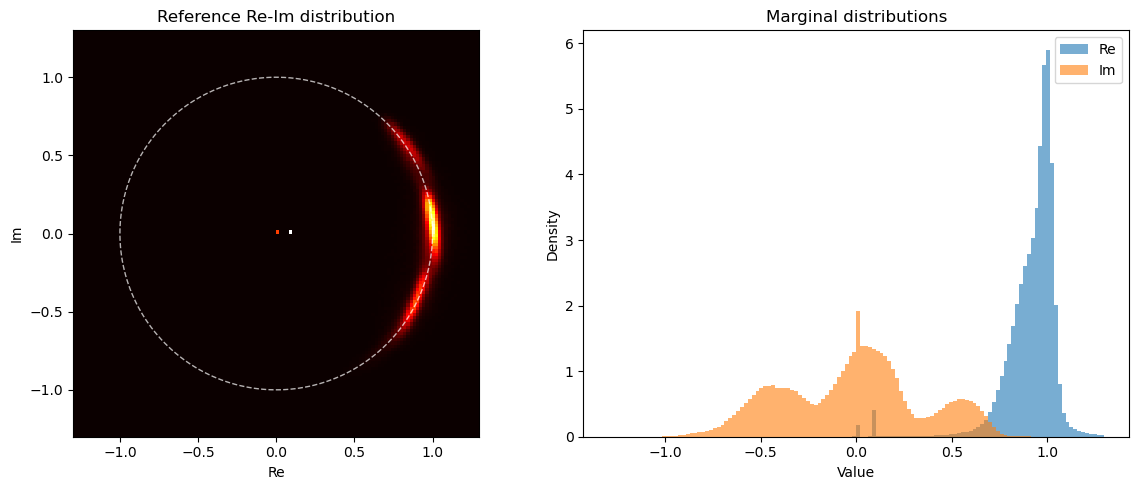

In [5]:
# Re-Im distribution of the reference object
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

hist_range = [[-1.3, 1.3], [-1.3, 1.3]]
bins = 128

# 2D joint histogram
axes[0].hist2d(ref_obj.real.ravel(), ref_obj.imag.ravel(),
               bins=bins, range=hist_range, cmap='hot')
theta = np.linspace(0, 2 * np.pi, 200)
axes[0].plot(np.cos(theta), np.sin(theta), 'w--', linewidth=1.0, alpha=0.7)
axes[0].set_xlabel('Re')
axes[0].set_ylabel('Im')
axes[0].set_title('Reference Re-Im distribution')
axes[0].set_aspect('equal')

# Marginal histograms
axes[1].hist(ref_obj.real.ravel(), bins=bins, range=(-1.3, 1.3),
             alpha=0.6, label='Re', density=True)
axes[1].hist(ref_obj.imag.ravel(), bins=bins, range=(-1.3, 1.3),
             alpha=0.6, label='Im', density=True)
axes[1].set_title('Marginal distributions')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 2. Fit Distribution Models

Three distribution models are fitted from the reference object. Different object generation methods require different models. Bottom two are most relevant, as they sample directly from the object statistics:

| Model | Function | Used by |
|---|---|---|
| **Re-Im statistics** | `compute_reim_statistics()` | `perlin_reim` |
| **2D histogram PDF** | `create_density_histogram_reim()` | `dead_leaves_reim_hist`, `dead_leaves` |
| **Gaussian Mixture Model** | `fit_gmm_from_objects()` | `dead_leaves_reim_gmm`, `white_noise_clustered` |

We fit all three here so any method can be used in the next section.

Albert's notes:
The 2d histogram PDF just samples real-imaginary values from the empirical distribution
The gaussian mixture model tries to get the overall "modes" (i.e. dominant regions) in the image, such as background, different types of contrasted features, etc.

In [6]:
ref_obj_list = [ref_obj]

# 1. Re-Im statistics
stats = compute_reim_statistics(ref_obj_list)
print('Re-Im statistics:')
for key in ['re_mean', 'im_mean', 're_std', 'im_std', 'correlation']:
    print(f'  {key}: {stats[key]:.4f}')

# 2. 2D histogram PDF
histogram, re_edges, im_edges = create_density_histogram_reim(
    ref_obj_list, origin_mask_radius=0.4,
)
print(f'\nHistogram: shape={histogram.shape}')

# 3. Gaussian Mixture Model
gmm_params = fit_gmm_from_objects(
    ref_obj_list, n_clusters=3, origin_mask_radius=0.4
)
print(f'\nGMM clusters: {gmm_params["n_clusters"]}')
print(f'Cluster weights: {gmm_params["weights"].round(3)}')
print(f'Cluster means (Re, Im):')
for i, m in enumerate(gmm_params['means']):
    print(f'  k={i}: ({m[0]:.3f}, {m[1]:.3f})')

Re-Im statistics:
  re_mean: 0.9186
  im_mean: -0.0225
  re_std: 0.1472
  im_std: 0.3629
  correlation: 0.0620
Re-Im histogram vacuum mode: Re=1.0008, Im=0.0602

Histogram: shape=(256, 256)
n_clusters is: 3
GMM fit: K=3, centers=([0.9, 0.996, 0.843], [-0.354, 0.071, 0.526]), weights=[0.407, 0.416, 0.178], vacuum=(0.996, 0.071)

GMM clusters: 3
Cluster weights: [0.407 0.416 0.178]
Cluster means (Re, Im):
  k=0: (0.900, -0.354)
  k=1: (0.996, 0.071)
  k=2: (0.843, 0.526)


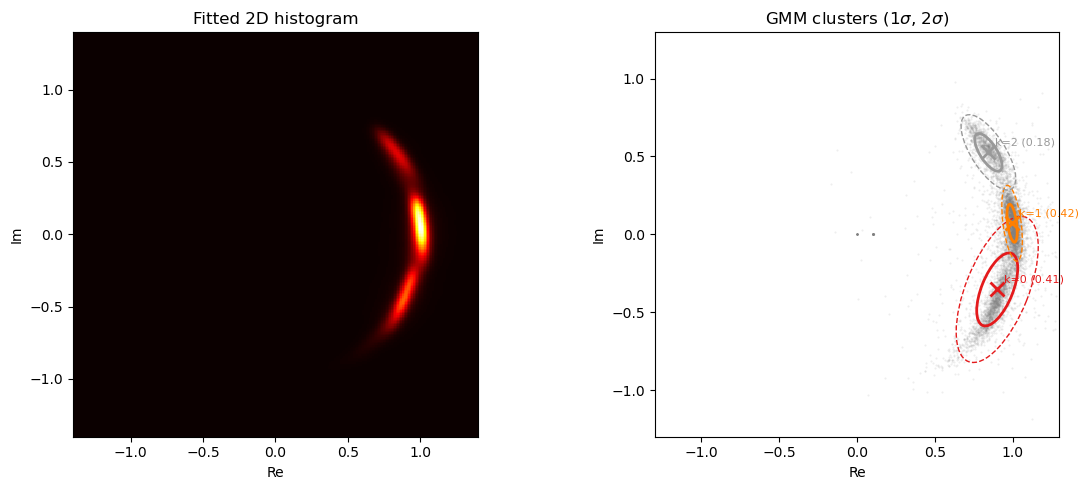

In [7]:
# Visualize fitted distribution models
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: 2D histogram heatmap
re_c = 0.5 * (re_edges[:-1] + re_edges[1:])
im_c = 0.5 * (im_edges[:-1] + im_edges[1:])
axes[0].pcolormesh(re_c, im_c, histogram.T, cmap='hot')
axes[0].set_xlabel('Re')
axes[0].set_ylabel('Im')
axes[0].set_title('Fitted 2D histogram')
axes[0].set_aspect('equal')

# Right: scatter + GMM ellipses
flat = ref_obj.ravel()
subsample = flat[::max(1, len(flat) // 8000)]
axes[1].scatter(subsample.real, subsample.imag, s=0.2, alpha=0.15,
                c='gray', rasterized=True)

means = gmm_params['means']
covs = gmm_params['covariances']
weights = gmm_params['weights']
colors = plt.cm.Set1(np.linspace(0, 1, len(weights)))

for k in range(len(weights)):
    eigvals, eigvecs = np.linalg.eigh(covs[k])
    angle = np.degrees(np.arctan2(eigvecs[1, 1], eigvecs[0, 1]))
    for n_std in [1, 2]:
        ell = Ellipse(
            xy=means[k],
            width=2 * n_std * np.sqrt(eigvals[1]),
            height=2 * n_std * np.sqrt(eigvals[0]),
            angle=angle,
            edgecolor=colors[k], facecolor='none',
            linewidth=2 if n_std == 1 else 1,
            linestyle='-' if n_std == 1 else '--',
        )
        axes[1].add_patch(ell)
    axes[1].plot(means[k, 0], means[k, 1], 'x', color=colors[k],
                 markersize=10, markeredgewidth=2)
    axes[1].annotate(f'k={k} ({weights[k]:.2f})', means[k], fontsize=8,
                     color=colors[k], textcoords='offset points', xytext=(5, 5))

axes[1].set_xlabel('Re')
axes[1].set_ylabel('Im')
axes[1].set_title(r'GMM clusters (1$\sigma$, 2$\sigma$)')
axes[1].set_aspect('equal')
axes[1].set_xlim(-1.3, 1.3)
axes[1].set_ylim(-1.3, 1.3)

plt.tight_layout()
plt.show()

---
## 3. Select and Configure Object Generation Method

PtychoPINN provides **13 synthetic object generation methods**. Choose one by setting `OBJ_METHOD` below.

### Methods requiring no extra data

| Method string | Description |
|---|---|
| `white_noise` | Uniform white noise mapped to amplitude/phase |
| `blurred_white_noise` | Gaussian-blurred white noise |
| `simplex_noise` | Perlin/simplex noise-based structures |
| `procedural` | Layered geometric shapes with Perlin texture |
| `polyhedra` | 3D polyhedra projection |
| `dead_leaves_reim` | Dead leaves with bivariate Gaussian Re-Im values |
| `dead_leaves_constrained` | Dead leaves with constrained phase range |
| `dead_leaves_reim_uniform` | Dead leaves with uniform Re-Im sampling |

### Methods requiring a fitted histogram

| Method string | Description |
|---|---|
| `dead_leaves` | Physics-based dead leaves with optional histogram sampling |
| `dead_leaves_reim_hist` | Dead leaves sampling from the fitted 2D histogram |

### Methods requiring fitted Re-Im statistics

| Method string | Description |
|---|---|
| `perlin_reim` | Correlated Perlin noise matched to Re-Im statistics |

### Methods requiring a fitted GMM

| Method string | Description |
|---|---|
| `dead_leaves_reim_gmm` | Dead leaves with GMM-sampled Re-Im values (recommended) |
| `white_noise_clustered` | Quantized noise mapped to GMM clusters |

In [8]:
# ============================================================
# SELECT YOUR OBJECT METHOD — change OBJ_METHOD to try others
# ============================================================
OBJ_METHOD = 'dead_leaves_reim_gmm'

# --- Automatic obj_arg construction (no need to edit below) ---
obj_arg = {}

# Mode mapping for create_dead_leaves_v3-based methods
MODE_MAP = {
    'dead_leaves_reim': 'gaussian',
    'dead_leaves_reim_hist': 'histogram',
    'dead_leaves_constrained': 'constrained_phase',
    'dead_leaves_reim_uniform': 'uniform',
}
if OBJ_METHOD in MODE_MAP:
    obj_arg['mode'] = MODE_MAP[OBJ_METHOD]

# White noise methods need a blur flag
if OBJ_METHOD in ('white_noise', 'blurred_white_noise'):
    obj_arg['blur'] = (OBJ_METHOD == 'blurred_white_noise')

# GMM-based methods need gmm_params and perturbation settings
# Most of these can be ignored or left as-is. They simply change how "varied" the samples are from our synthetic distribution.
# larger number generally means more noise
if OBJ_METHOD in ('dead_leaves_reim_gmm', 'white_noise_clustered'):
    obj_arg['gmm_params'] = gmm_params
    obj_arg['perturbation_mode'] = 'physical'
    obj_arg['phase_jitter_std'] = 0.1
    obj_arg['amplitude_scale_std'] = 0.03
    obj_arg['center_jitter_std'] = 0.05
    obj_arg['weight_dirichlet_conc'] = 5.0
    obj_arg['clip_range'] = (-1.2, 1.2)

# Build extra kwargs for simulate_synthetic_objects
gen_kwargs = {}
if OBJ_METHOD in ('dead_leaves', 'dead_leaves_reim_hist'):
    gen_kwargs['histogram'] = histogram
if OBJ_METHOD == 'perlin_reim':
    gen_kwargs['stats'] = stats

print(f'Selected method: {OBJ_METHOD}')
print(f'obj_arg keys: {list(obj_arg.keys())}')
if gen_kwargs:
    print(f'Extra kwargs: {list(gen_kwargs.keys())}')

Selected method: dead_leaves_reim_gmm
obj_arg keys: ['gmm_params', 'perturbation_mode', 'phase_jitter_std', 'amplitude_scale_std', 'center_jitter_std', 'weight_dirichlet_conc', 'clip_range']


---
## 4. Generate and Visualize Sample Objects

Generate a small batch of synthetic objects for visual inspection before committing to the full dataset. Compare amplitude/phase images and Re-Im distributions against the reference.

In [9]:
data_config = DataConfig(N=N)

n_preview = 3
sample_objects = simulate_synthetic_objects(
    IMAGE_SIZE, data_config, nimages=n_preview,
    obj_method=OBJ_METHOD, obj_arg=obj_arg,
    **gen_kwargs
)

for i, obj in enumerate(sample_objects):
    print(f'Object {i}: shape={obj.shape}, '
          f'amp=[{np.abs(obj).min():.3f}, {np.abs(obj).max():.3f}], '
          f'Re=[{obj.real.min():.3f}, {obj.real.max():.3f}]')

create_dead_leaves_reim_gmm: generated (500, 500) object, K=3, 3000 leaves
create_dead_leaves_reim_gmm: generated (500, 500) object, K=3, 2500 leaves
create_dead_leaves_reim_gmm: generated (500, 500) object, K=3, 2500 leaves
Object 0: shape=(500, 500), amp=[0.609, 1.243], Re=[0.424, 1.200]
Object 1: shape=(500, 500), amp=[0.542, 1.282], Re=[0.449, 1.200]
Object 2: shape=(500, 500), amp=[0.554, 1.171], Re=[0.340, 1.110]


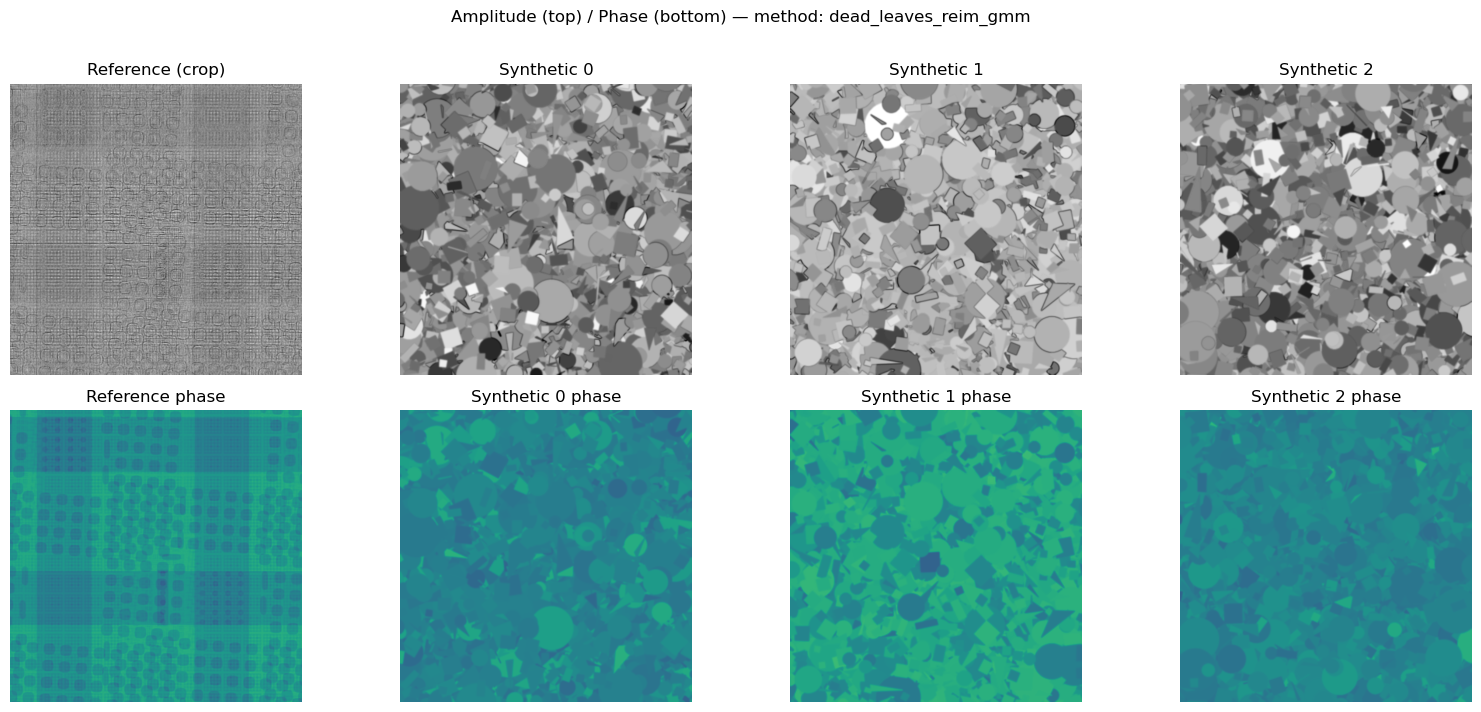

In [10]:
# Amplitude/phase comparison: reference (center-cropped) vs synthetic objects
h, w = IMAGE_SIZE
exp_crop = ref_obj[
    ref_obj.shape[0] // 2 - h // 2 : ref_obj.shape[0] // 2 + h // 2,
    ref_obj.shape[1] // 2 - w // 2 : ref_obj.shape[1] // 2 + w // 2,
]

n_cols = 1 + n_preview
fig, axes = plt.subplots(2, n_cols, figsize=(4 * n_cols, 7))

# Reference (cropped)
axes[0, 0].imshow(np.abs(exp_crop), cmap='gray')
axes[0, 0].set_title('Reference (crop)')
axes[0, 0].axis('off')
axes[1, 0].imshow(np.angle(exp_crop), cmap='viridis', vmin=-np.pi, vmax=np.pi)
axes[1, 0].set_title('Reference phase')
axes[1, 0].axis('off')

# Synthetic objects
for i in range(n_preview):
    obj = sample_objects[i]
    axes[0, i + 1].imshow(np.abs(obj), cmap='gray')
    axes[0, i + 1].set_title(f'Synthetic {i}')
    axes[0, i + 1].axis('off')
    axes[1, i + 1].imshow(np.angle(obj), cmap='viridis', vmin=-np.pi, vmax=np.pi)
    axes[1, i + 1].set_title(f'Synthetic {i} phase')
    axes[1, i + 1].axis('off')

plt.suptitle(f'Amplitude (top) / Phase (bottom) — method: {OBJ_METHOD}', y=1.01)
plt.tight_layout()
plt.show()

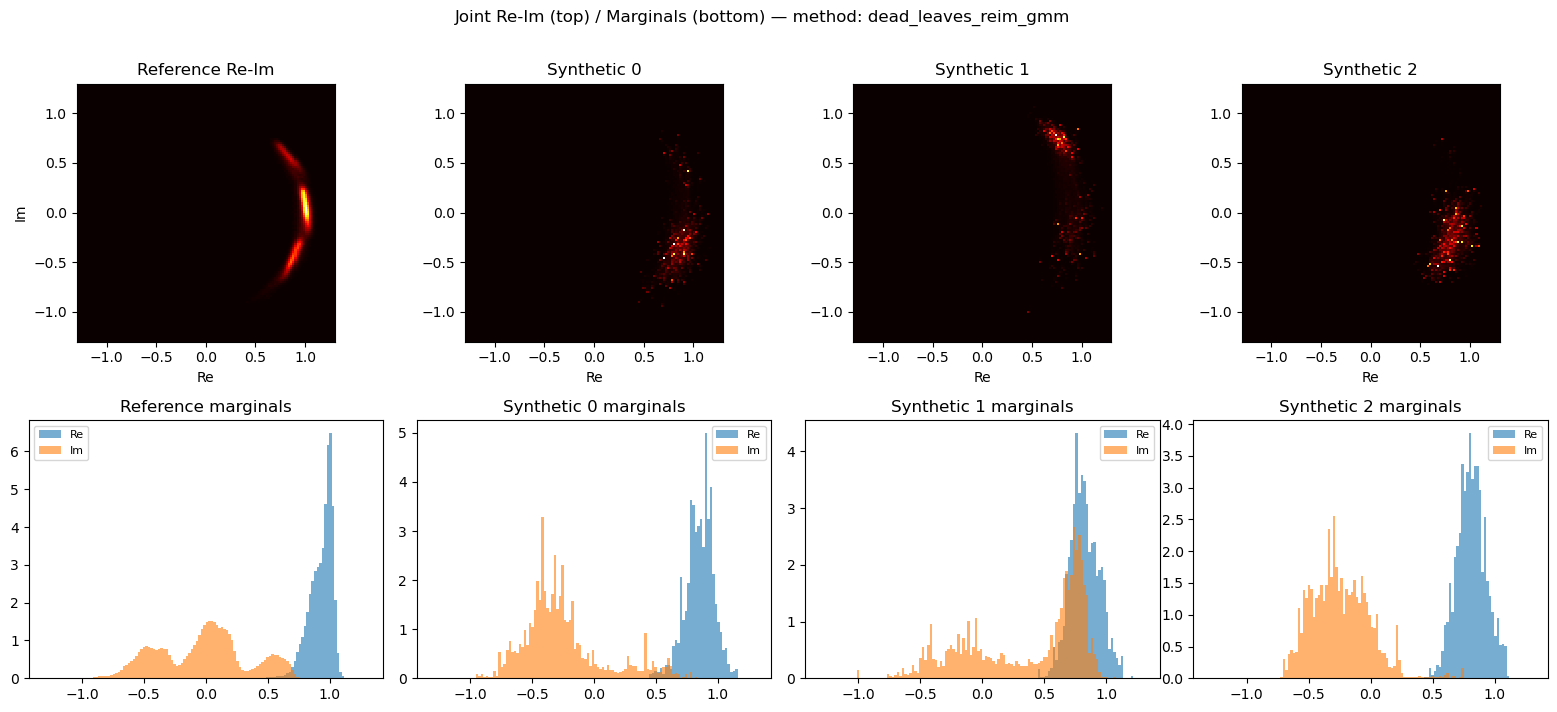

In [11]:
# Re-Im distribution comparison: reference vs synthetic objects
n_cols = 1 + n_preview
fig, axes = plt.subplots(2, n_cols, figsize=(4 * n_cols, 7))
hist_range = [[-1.3, 1.3], [-1.3, 1.3]]
bins = 128

# Reference distributions
axes[0, 0].hist2d(exp_crop.real.ravel(), exp_crop.imag.ravel(),
                  bins=bins, range=hist_range, cmap='hot')
axes[0, 0].set_title('Reference Re-Im')
axes[0, 0].set_xlabel('Re')
axes[0, 0].set_ylabel('Im')
axes[0, 0].set_aspect('equal')

axes[1, 0].hist(exp_crop.real.ravel(), bins=bins, range=(-1.3, 1.3),
                alpha=0.6, label='Re', density=True)
axes[1, 0].hist(exp_crop.imag.ravel(), bins=bins, range=(-1.3, 1.3),
                alpha=0.6, label='Im', density=True)
axes[1, 0].set_title('Reference marginals')
axes[1, 0].legend(fontsize=8)

# Synthetic distributions
for i in range(n_preview):
    obj = sample_objects[i]
    axes[0, i + 1].hist2d(obj.real.ravel(), obj.imag.ravel(),
                          bins=bins, range=hist_range, cmap='hot')
    axes[0, i + 1].set_title(f'Synthetic {i}')
    axes[0, i + 1].set_xlabel('Re')
    axes[0, i + 1].set_aspect('equal')

    axes[1, i + 1].hist(obj.real.ravel(), bins=bins, range=(-1.3, 1.3),
                        alpha=0.6, label='Re', density=True)
    axes[1, i + 1].hist(obj.imag.ravel(), bins=bins, range=(-1.3, 1.3),
                        alpha=0.6, label='Im', density=True)
    axes[1, i + 1].set_title(f'Synthetic {i} marginals')
    axes[1, i + 1].legend(fontsize=8)

plt.suptitle(f'Joint Re-Im (top) / Marginals (bottom) — method: {OBJ_METHOD}', y=1.01)
plt.tight_layout()
plt.show()

---
## 5. Generate Full Synthetic Dataset

Generate the complete training dataset. This produces `N_OBJECTS` synthetic experiments, each containing `DIFF_PER_OBJECT` simulated diffraction patterns.

Each saved NPZ file contains:
- `diff3d` — simulated diffraction intensity patterns
- `label` — ground truth object patches at each scan position
- `objectGuess` — the full synthetic object
- `probeGuess` — the probe function used for simulation
- `xcoords`, `ycoords` — scan positions

In [12]:
# Generate all synthetic objects
print(f'Generating {N_OBJECTS} objects with \'{OBJ_METHOD}\'...')
obj_list = simulate_synthetic_objects(
    IMAGE_SIZE, data_config, nimages=N_OBJECTS,
    obj_method=OBJ_METHOD, obj_arg=obj_arg,
    **gen_kwargs
)

# Prepare probe list (reuse the reference probe for all objects)
probe_list = [probe] * N_OBJECTS
probe_name_idx = list(range(N_OBJECTS))
probe_arg = {
    'probe_name_idx': probe_name_idx,
    'beamstop_diameter': 4,
}

# Prepare output directory
os.makedirs(SYNTHETIC_DATA_DIR, exist_ok=True)
if os.listdir(SYNTHETIC_DATA_DIR):
    print(f'Clearing existing files in {SYNTHETIC_DATA_DIR}...')
    remove_all_files(SYNTHETIC_DATA_DIR)

# Simulate diffraction and save NPZs
simulate_multiple_experiments(
    obj_list, probe_list, DIFF_PER_OBJECT,
    IMAGE_SIZE, data_config, probe_arg, SYNTHETIC_DATA_DIR,
)

# Verify saved files
saved_files = sorted(f for f in os.listdir(SYNTHETIC_DATA_DIR) if f.endswith('.npz'))
print(f'\nSaved {len(saved_files)} experiment files to {SYNTHETIC_DATA_DIR}')
for f in saved_files:
    with np.load(os.path.join(SYNTHETIC_DATA_DIR, f)) as d:
        print(f'  {f}: diff3d={d["diff3d"].shape}, label={d["label"].shape}')

Generating 4 objects with 'dead_leaves_reim_gmm'...
create_dead_leaves_reim_gmm: generated (500, 500) object, K=3, 3000 leaves
create_dead_leaves_reim_gmm: generated (500, 500) object, K=3, 3000 leaves
create_dead_leaves_reim_gmm: generated (500, 500) object, K=3, 2500 leaves
create_dead_leaves_reim_gmm: generated (500, 500) object, K=3, 2500 leaves
Clearing existing files in ../../data/synthetic_pipeline_demo...
Removed 4 files from '../../data/synthetic_pipeline_demo'
----Beginning simulation for experiment 0----
Beginning simulation...
Processing 7000 images in batches of 1000...
  Getting image patches...
  Diffracting...
  Poisson scaling...
  Getting image patches...
  Diffracting...
  Poisson scaling...
  Getting image patches...
  Diffracting...
  Poisson scaling...
  Getting image patches...
  Diffracting...
  Poisson scaling...
  Getting image patches...
  Diffracting...
  Poisson scaling...
  Getting image patches...
  Diffracting...
  Poisson scaling...
  Getting image patc

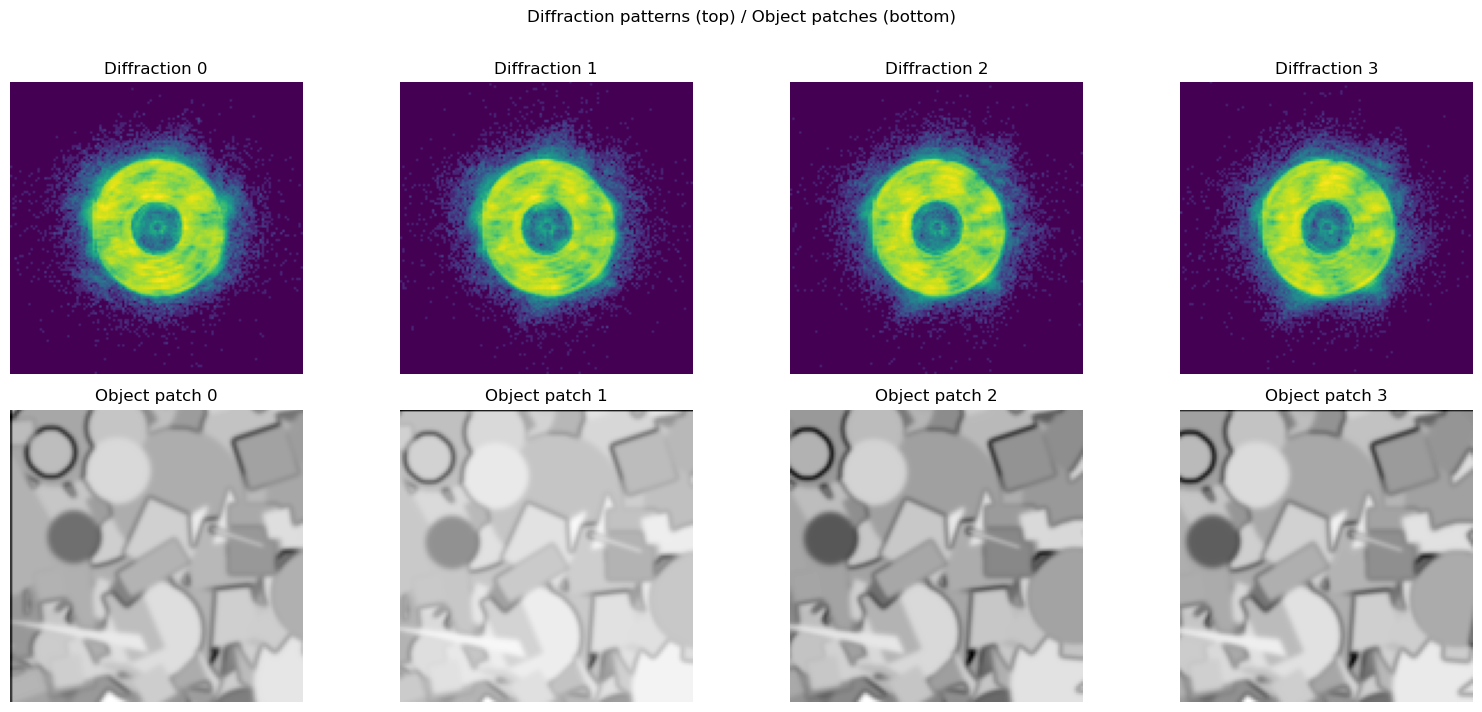

In [13]:
# Sanity check: visualize a few diffraction patterns and object patches from the first saved file
check_file = os.path.join(SYNTHETIC_DATA_DIR, saved_files[0])
check_data = np.load(check_file)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for i in range(4):
    # Diffraction patterns (log scale)
    axes[0, i].imshow(np.log1p(check_data['diff3d'][i]), cmap='viridis')
    axes[0, i].set_title(f'Diffraction {i}')
    axes[0, i].axis('off')

    # Object patches (amplitude)
    axes[1, i].imshow(np.abs(check_data['label'][i]), cmap='gray')
    axes[1, i].set_title(f'Object patch {i}')
    axes[1, i].axis('off')

plt.suptitle('Diffraction patterns (top) / Object patches (bottom)', y=1.01)
plt.tight_layout()
plt.show()

check_data.close()

---
## 6. Configure and Run CCNF Training

Train the PC-CCNF model via `train_ccnf.main()` with the indexed dataloader.
Returns `(model, trainer, run_dir)` — same interface as `main_lightning()`.

### How training differs from the default UNet loop

#### Config delivery

`main_lightning()` accepts an `existing_config` tuple of dataclass objects directly.
`train_ccnf.main()` requires a **JSON config file path** — so we serialize the
config dataclasses to JSON before calling it. The config is saved to
`TRAINING_OUTPUT_DIR/ccnf_config.json` for reproducibility.

#### Dataloader: `PtychoDatasetIndexed` vs `PtychoDataset`

The standard `PtychoDataset` **pre-groups** C neighboring diffraction patterns
into the memory map at initialization. Each pattern is duplicated across every
group it belongs to, yielding a map of shape `(N_groups, C, H, W)`. Groups are
fixed for the entire training run.

`PtychoDatasetIndexed` instead stores each pattern **exactly once** in the
memory map as `(N_patterns, H, W)`, reducing disk/memory footprint by ~C×.
A `NeighborGraph` pre-computes a KD-tree candidate pool, and `__getitem__`
gathers C patterns on the fly from stored indices. Groups can be **resampled
each epoch** via overlap-based greedy selection with softmax temperature,
providing training-time data augmentation that the fixed-group dataloader
cannot offer.

#### Model forward pass

The standard `PtychoPINN` autoencoder processes all C channels simultaneously
through an encoder-decoder and **never sees scan positions** — positions are
only used downstream in the `ForwardModel` for patch reassembly.

`PtychoPINN_CCNF` passes positions and probe into the autoencoder itself:
1. **Weight-shared encoder** processes each patch independently (B×C → B×C latents)
2. **Geometry-tagged cross-attention** splats latents onto a shared canvas using
   Fourier-encoded position offsets — positions directly condition the fusion
3. **Neural field decoder** queries the canvas at coordinate-conditioned points,
   so the decoder output is explicitly tied to spatial location

This means the CCNF model learns position-dependent representations,
whereas the UNet treats all patches identically regardless of where they sit
in the scan.

### Key CCNF configuration parameters

| Parameter | Default | Notes |
|---|---|---|
| `architecture` | `ccnf` | Selects the PC-CCNF architecture |
| `encoder_type` | `fno_cnn` | FNO+CNN hybrid encoder; alternative: `cnn` |
| `ccnf_decoder_type` | `neural_field` | Coordinate-conditioned MLP; alternative: `cnn` |
| `C` | `8` | Neighbor patches per group (higher than UNet default of 4) |
| `latent_canvas_size` | `16` | Latent canvas resolution for fusion |
| `learning_rate` | `1e-4` | Lower than UNet due to attention layers |
| `batch_size` | `16` | Reduce if GPU memory is limited |
| `fusion_heads` | `4` | Multi-head attention heads in canvas fusion |
| `fourier_bands_coord` | `6` | Frequency bands for coordinate encoding |
| `neural_field_hidden` | `[512, 256, 128]` | MLP layer widths in neural field decoder |

**Note for Hanna**:

Dynamically adjust the batch size so it barely fits on your gpu. You may need to do some limit testing to see at what batch sizes the training fails. 

Additionally, change the number of devices to 2 when running outside a notebook, since we'd have to switch over to another distributed method to run in notebooks which makes things a bit annoying. Training should be a bit faster, although I still recommend training these on a cluster.

You can find relevant configs on eagle at: /APSDataAnalysis/avong/ptychopinn/configs/

Specifically relevant is the ccnf_128.json, which successfully ran on the base batch size of 16 with 4 gpus.

In [ ]:
# CCNF training configuration
data_config = DataConfig(
    N=N,
    C=8,
    neighbor_function='Nearest',
    normalize='Batch',
    probe_normalize=True,
    x_bounds=(0.05, 0.95),
    y_bounds=(0.05, 0.95),
    scan_pattern='Isotropic',
)

model_config = ModelConfig(
    mode='Unsupervised',
    architecture='ccnf',
    encoder_type='fno_cnn',
    ccnf_decoder_type='cnn',
    loss_function='Poisson',
    intensity_scale_trainable=True,
    n_filters_scale=2,
    cbam_encoder=True,
    cbam_bottleneck=False,
    batch_norm=False,
    latent_canvas_size=32,
    fusion_heads=4,
    fusion_tag_bands=3,
    feature_volume_channels=64,
    fourier_bands_coord=6,
    fno_interleave=True,
    fno_modes=32
)

training_config = TrainingConfig(
    epochs=2,
    batch_size=6,
    accum_steps=2,
    learning_rate=1e-4,
    n_devices=1,
    num_workers=4,
    scheduler='Cosine',
    gradient_clip_val=1.0,
    experiment_name='CCNF_pipeline_demo',
)

inference_config = InferenceConfig()
datagen_config = DatagenConfig()

# Serialize configs to JSON for train_ccnf.main()
config_dict = {
    'data_config': config_to_json_serializable_dict(data_config),
    'model_config': config_to_json_serializable_dict(model_config),
    'training_config': config_to_json_serializable_dict(training_config),
    'inference_config': config_to_json_serializable_dict(inference_config),
    'datagen_config': config_to_json_serializable_dict(datagen_config),
}

os.makedirs(TRAINING_OUTPUT_DIR, exist_ok=True)
if CCNF_CONFIG_PATH is None:
    CCNF_CONFIG_PATH = os.path.join(TRAINING_OUTPUT_DIR, 'ccnf_config.json')
with open(CCNF_CONFIG_PATH, 'w') as f:
    json.dump(config_dict, f, indent=2)

print(f'Config written to: {CCNF_CONFIG_PATH}')
print(f'\nCCNF configuration:')
print(f'  Architecture: {model_config.architecture}')
print(f'  Encoder: {model_config.encoder_type}')
print(f'  Decoder: {model_config.ccnf_decoder_type}')
print(f'  C (neighbors): {data_config.C}')
print(f'  Latent canvas: {model_config.latent_canvas_size}')
print(f'  Epochs: {training_config.epochs}')
print(f'  Batch size: {training_config.batch_size}')
print(f'  Learning rate: {training_config.learning_rate}')
print(f'  Patch size N: {data_config.N}')

Config written to: ../../data/ccnf_training_pipeline_demo/ccnf_config.json

CCNF configuration:
  Architecture: ccnf
  Encoder: fno_cnn
  Decoder: cnn
  C (neighbors): 8
  Latent canvas: 32
  Epochs: 2
  Batch size: 6
  Learning rate: 0.0001
  Patch size N: 128


In [15]:
model, trainer, run_dir = train_ccnf_main(
    ptycho_dir=SYNTHETIC_DATA_DIR,
    config_path=CCNF_CONFIG_PATH,
    output_dir=TRAINING_OUTPUT_DIR,
)

print(f'\nTraining complete!')
print(f'Run directory: {run_dir}')

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:You are using a CUDA device ('NVIDIA GeForce RTX 4070') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


Loading configs...
Successfully loaded configuration from: ../../data/ccnf_training_pipeline_demo/ccnf_config.json
Configuration validation completed.
num_datasets set to 4 (from ../../data/synthetic_pipeline_demo)
Architecture: ccnf
Encoder type: fno_cnn
Decoder type: cnn
C=8, N=128, devices=1
Learning rate: 0.000100
Starting training for 2 epochs...
Creating indexed memory mapped tensor dictionary...
Allocating pattern store for 28000 patterns...
Pattern store allocated in 0.0s
Detected multi-mode probes: max 5 modes
Processing experiment 0: ../../data/synthetic_pipeline_demo/synthetic_0.npz
Processing experiment 1: ../../data/synthetic_pipeline_demo/synthetic_1.npz
Processing experiment 2: ../../data/synthetic_pipeline_demo/synthetic_2.npz
Processing experiment 3: ../../data/synthetic_pipeline_demo/synthetic_3.npz
Index-only dataset built: 28000 patterns, 158977 groups, C=8
[PtychoDatasetIndexed Rank 0] Init done. 28000 patterns, 158977 groups.
Loading existing indexed dataset on ra

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name  | Type            | Params | Mode 
--------------------------------------------------
0 | model | PtychoPINN_CCNF | 4.7 M  | train
1 | Loss  | PoissonLoss     | 0      | train
--------------------------------------------------
4.7 M     Trainable params
0         Non-trainable params
4.7 M     Total params
18.915    Total estimated model params size (MB)
134       Modules in train mode
0         Modules in eval mode


[PtychoDatasetIndexed Rank 0] Init done. 28000 patterns, 158977 groups.
Dataset split: Total=158977, Train=151029, Val=7948
[Rank 0] Created unique run directory: ../../data/ccnf_training_pipeline_demo/CCNF_pipeline_demo/run_20260629_093626
                                                                           

/local/miniconda3/envs/PtychoPINN_torch/lib/python3.10/site-packages/lightning/pytorch/core/module.py:512: You called `self.log('poisson_val_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`


Created metadata file at ../../data/ccnf_training_pipeline_demo/CCNF_pipeline_demo/run_20260629_093626/metadata.json
Epoch 0:   0%|          | 0/25172 [00:00<?, ?it/s] 
Starting Epoch 1/2
Epoch 0:   0%|          | 1/25172 [00:00<2:17:06,  3.06it/s, poisson_train_loss_step=6.34e+6]

/local/miniconda3/envs/PtychoPINN_torch/lib/python3.10/site-packages/lightning/pytorch/core/module.py:512: You called `self.log('poisson_train_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`


Epoch 0:   3%|▎         | 664/25172 [02:19<1:25:44,  4.76it/s, poisson_train_loss_step=8.86e+3]

INFO:pytorch_lightning.utilities.rank_zero:
Detected KeyboardInterrupt, attempting graceful shutdown ...


NameError: name 'exit' is not defined

In [ ]:
# List saved artifacts
print('Saved checkpoints:')
ckpt_dir = os.path.join(run_dir, 'checkpoints')
if os.path.exists(ckpt_dir):
    for f in sorted(os.listdir(ckpt_dir)):
        fpath = os.path.join(ckpt_dir, f)
        size_mb = os.path.getsize(fpath) / (1024 * 1024)
        print(f'  {f} ({size_mb:.1f} MB)')

print('\nSaved configs:')
configs_dir = os.path.join(run_dir, 'configs')
if os.path.exists(configs_dir):
    for f in sorted(os.listdir(configs_dir)):
        print(f'  {f}')

---
## 7. Run Inference

Run reconstruction on a **separate test dataset** using the CCNF indexed inference pipeline.
Set `INFERENCE_NPZ_PATH` in the configuration cell at the top of this notebook.

### How inference differs from the default loop

The standard notebook calls `load_and_predict_lightning()` — a single function
that loads the checkpoint, builds a `PtychoDataset`, runs reconstruction, and
saves plots in one shot.

The CCNF pipeline exposes four explicit steps, each from `inference_indexed.py`:

1. **`load_model_from_checkpoint()`** — loads the model and extracts all four
   config objects from the checkpoint. Accepts a run directory (auto-resolves
   to `checkpoints/best-checkpoint.ckpt` or `last.ckpt`).

2. **`build_indexed_dataset()`** — creates a `PtychoDatasetIndexed` for the
   inference data. This builds a fresh memory map with patterns stored once
   (not C× duplicated). It also constructs a synthetic `mmap_ptycho` TensorDict
   view so the downstream `reconstruct_image_barycentric()` can read
   `coords_global` in the format it expects.

3. **`run_reconstruction()`** — probe-weighted barycentric assembly, same
   underlying `reconstruct_image_barycentric()` as the UNet path. The
   difference is that patch groups are gathered at runtime from the index
   store rather than read from pre-assembled groups.

4. **`save_results()`** — saves amplitude/phase comparison plots (SVG),
   Re-Im histograms, individual PNGs, and raw `.npy` arrays.

**Batch size scaling:** The CCNF encoder processes B×C patches per forward pass.
With C=8, a batch of 100 means 800 encoder passes, so the default inference
batch size is scaled down to `max(4, 128 // C)` to avoid OOM.

In [ ]:
inference_data_dir = os.path.dirname(os.path.abspath(INFERENCE_NPZ_PATH))
os.makedirs(INFERENCE_OUTPUT_DIR, exist_ok=True)

print(f'Inference data directory: {inference_data_dir}')
print(f'Model from: {run_dir}')
print(f'Output to: {INFERENCE_OUTPUT_DIR}')

# Load model and configs from checkpoint
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model_infer, data_cfg, model_cfg, train_cfg, infer_cfg = load_model_from_checkpoint(
    run_dir, device=device
)
print(f'Architecture: {getattr(model_cfg, "architecture", "unet")}')
print(f'C={data_cfg.C}, N={data_cfg.N}, Device: {device}')

# Build indexed dataset
mmap_dir = os.path.join(INFERENCE_OUTPUT_DIR, 'memmap_inference')
dataset = build_indexed_dataset(
    inference_data_dir, model_cfg, data_cfg, train_cfg, mmap_dir=mmap_dir
)

# Configure inference
infer_cfg.experiment_number = 0
infer_cfg.batch_size = max(4, 128 // data_cfg.C)
print(f'Inference batch size: {infer_cfg.batch_size} (B*C={infer_cfg.batch_size * data_cfg.C})')

# Run reconstruction
result, subset, stats, modified = run_reconstruction(
    model_infer, dataset, data_cfg, model_cfg,
    train_cfg, infer_cfg, device=device,
)

# Save results
save_results(result, subset, INFERENCE_OUTPUT_DIR, infer_cfg, experiment_number=0)

print(f'\nInference complete!')
print(f'  Inference time: {stats[0]:.2f}s')
print(f'  Assembly time:  {stats[1]:.2f}s')
print(f'Result shape: {result.shape}')

---
## 8. Visualize Results

The inference function saves amplitude/phase comparison plots and Re-Im histograms as SVG files. Display them inline below.

In [ ]:
# Display all saved plots
svg_files = sorted(glob.glob(os.path.join(INFERENCE_OUTPUT_DIR, '*.svg')))

if svg_files:
    for svg_file in svg_files:
        print(f'\n{os.path.basename(svg_file)}:')
        display(SVG(filename=svg_file))
else:
    print('No SVG files found. Displaying reconstruction from result tensor...')
    result_np = result.cpu().numpy()
    if result_np.ndim == 3:
        result_np = result_np[0]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(np.abs(result_np), cmap='gray')
    axes[0].set_title('Reconstructed amplitude')
    axes[0].axis('off')

    axes[1].imshow(np.angle(result_np), cmap='twilight', vmin=-np.pi, vmax=np.pi)
    axes[1].set_title('Reconstructed phase')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
# Summary
result_np = result.cpu().numpy()
if result_np.ndim == 3:
    result_np = result_np[0]

print('=== CCNF Pipeline Summary ===')
print(f'Object method: {OBJ_METHOD}')
print(f'Architecture: ccnf (encoder={model_config.encoder_type}, decoder={model_config.ccnf_decoder_type})')
print(f'Training data: {N_OBJECTS} objects x {DIFF_PER_OBJECT} patterns')
print(f'Training epochs: {training_config.epochs}')
print(f'Reconstruction shape: {result_np.shape}')
print(f'Amplitude range: [{np.abs(result_np).min():.4f}, {np.abs(result_np).max():.4f}]')
print(f'Phase range: [{np.angle(result_np).min():.4f}, {np.angle(result_np).max():.4f}]')
print()
print('Next steps:')
print('  - Try a different OBJ_METHOD and re-run sections 3-5')
print('  - Increase training epochs for better convergence')
print('  - Experiment with encoder_type (fno_cnn vs cnn)')
print('  - Experiment with ccnf_decoder_type (neural_field vs cnn)')
print('  - Adjust latent_canvas_size (16 vs 32) for resolution/speed tradeoff')
print('  - Compare results with the UNet baseline (full_training_pipeline.ipynb)')